In [115]:
# This project develops a machine learning model to detect fraudulent credit card transactions using the Gradient Boosting Classifier. 
# The workflow includes data preprocessing, exploratory data analysis, model training, evaluation, and prediction.

In [63]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('creditcard.csv')

In [65]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
221196,142470.0,1.553785,-0.966682,-1.399271,0.034863,0.403692,1.068250,-0.080103,0.280328,0.779764,...,0.057845,0.132288,0.094579,-1.383433,-0.330926,-0.007218,-0.005774,-0.050256,177.44,0
177320,123128.0,1.282664,-2.428982,-1.260908,-0.674976,-1.045075,0.398198,-0.447833,0.046638,-0.102059,...,0.077838,-0.787276,0.008851,0.200433,-0.617765,-0.639807,-0.083135,0.026009,457.75,0
125163,77555.0,-4.315674,0.950762,1.180269,-4.167587,0.048713,2.044032,0.274844,-3.696033,4.743289,...,1.197730,0.222850,0.017534,-1.541786,-0.291755,-0.155996,-0.829858,-1.553498,40.80,0
109663,71481.0,1.146238,-0.299269,0.605065,0.149248,-0.843801,-0.547092,-0.251279,-0.011458,0.492831,...,-0.031129,0.057524,-0.073663,0.640258,0.377319,1.078432,-0.075569,-0.002875,35.95,0
240512,150633.0,1.870644,-0.160476,-1.279741,0.827098,-0.224145,-1.139753,0.042423,-0.255566,0.725745,...,-0.063803,-0.176718,0.142696,-0.035258,-0.237908,0.209510,-0.037660,-0.012620,80.95,0


In [66]:
df.shape

(284807, 31)

In [67]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [68]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [69]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [70]:
df.duplicated().sum()

np.int64(1081)

In [71]:
df = df.drop_duplicates() 

In [72]:
df.shape

(283726, 31)

In [73]:
# EDA Analysis

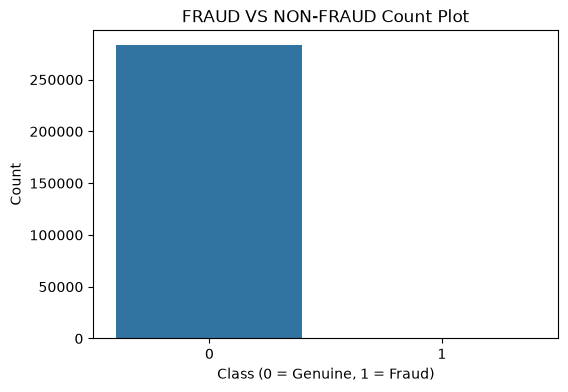

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)
plt.title("FRAUD VS NON-FRAUD Count Plot")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

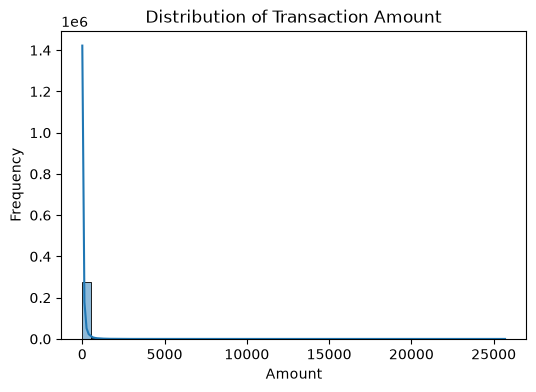

In [75]:
plt.figure(figsize=(6,4))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

Text(0, 0.5, 'Frequency')

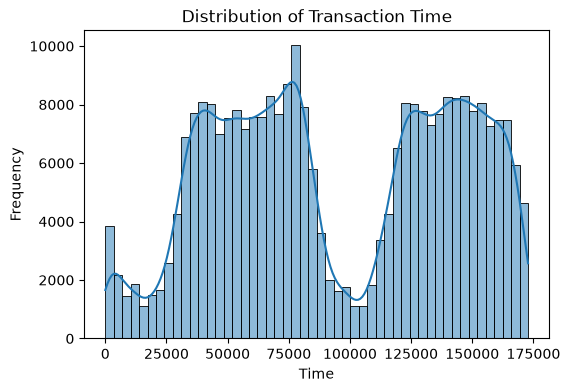

In [76]:
plt.figure(figsize=(6,4))

sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")

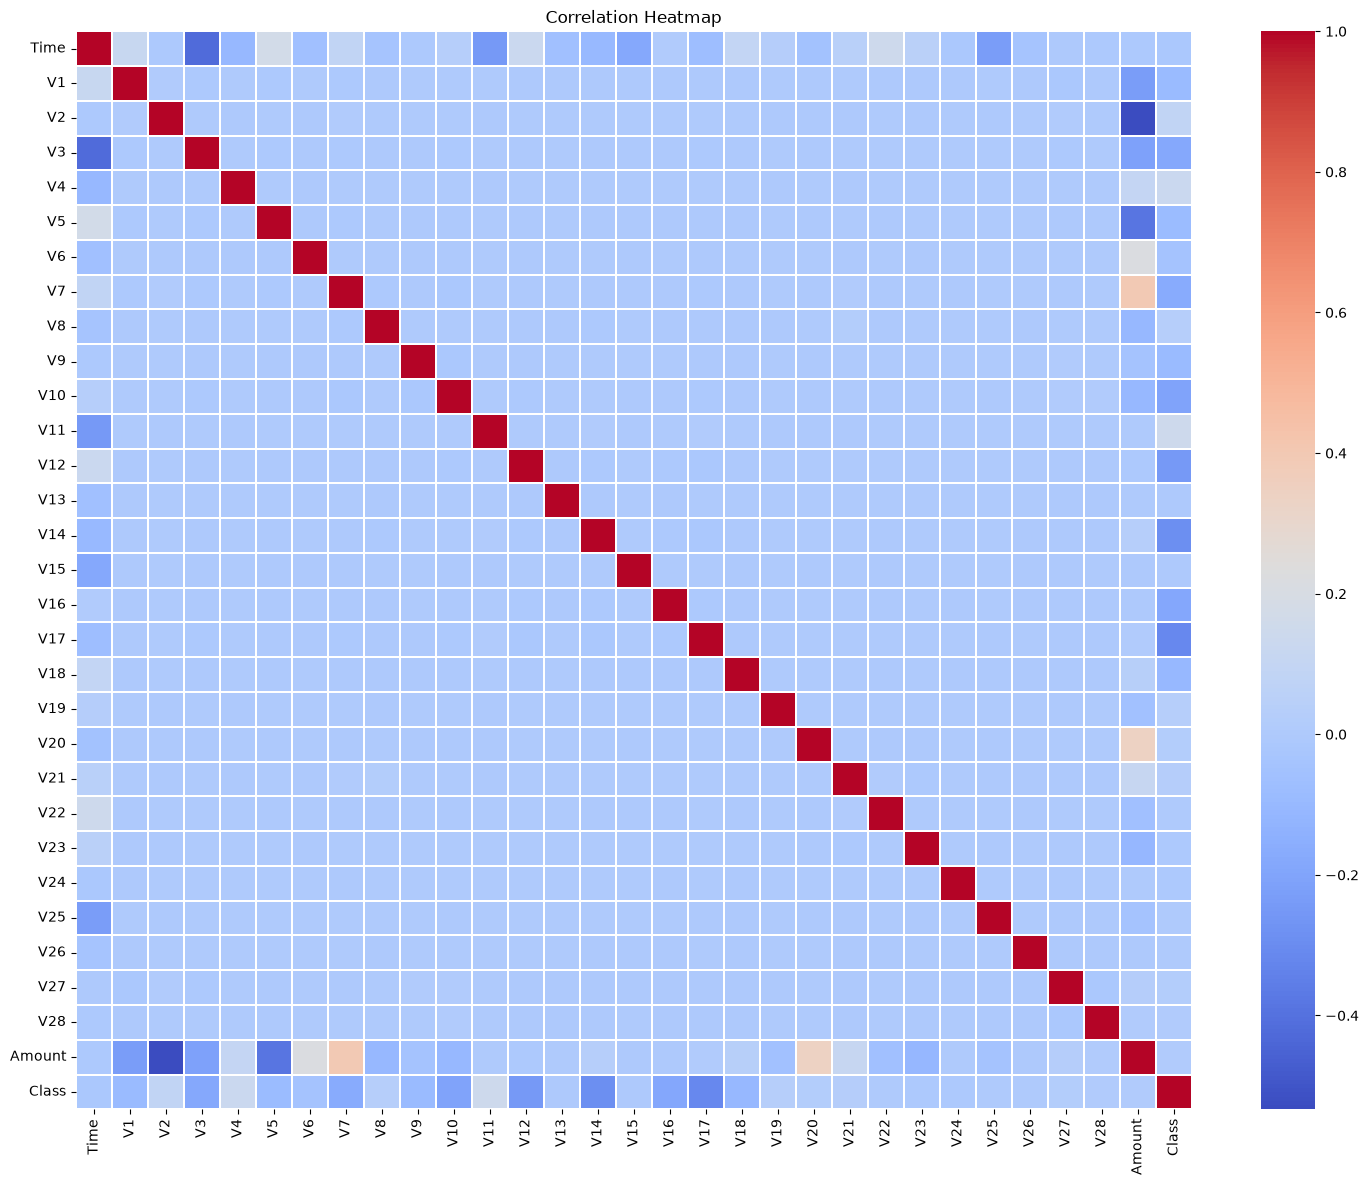

In [77]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.3)

plt.title("Correlation Heatmap")
plt.show()

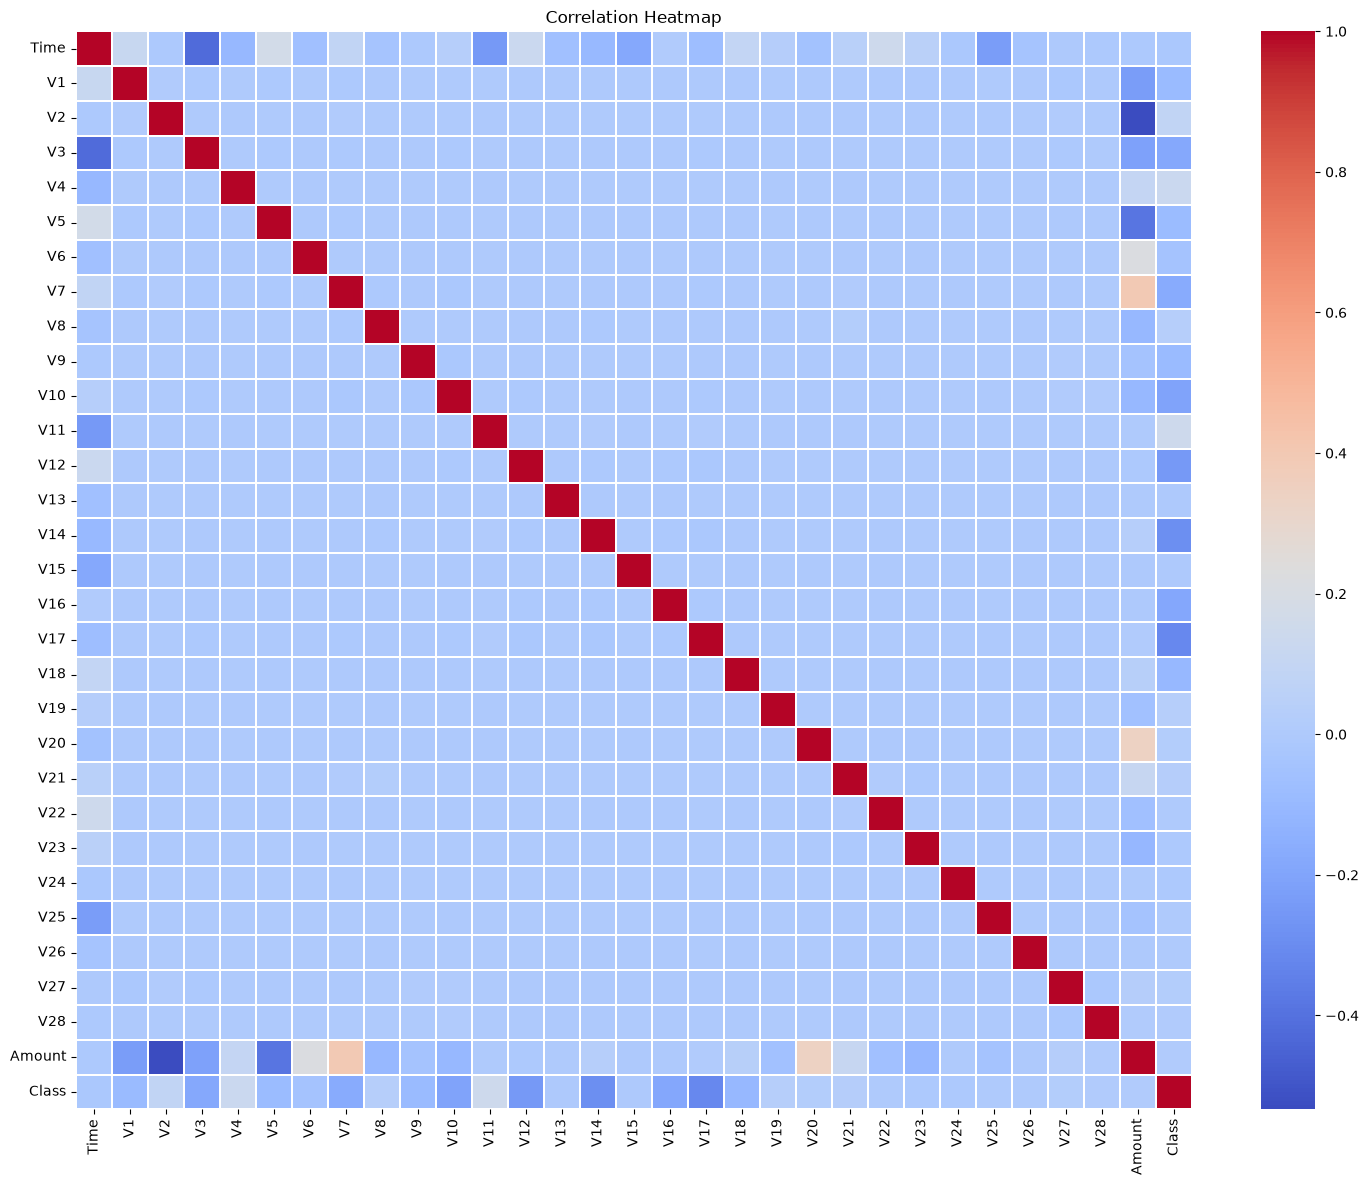

In [78]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.3, xticklabels=True, yticklabels=True)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Correlation Heatmap")
plt.show()

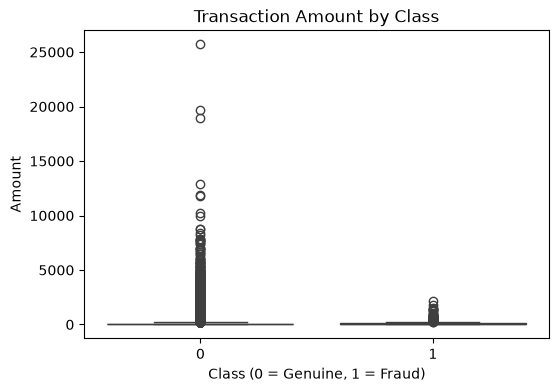

In [79]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()
            

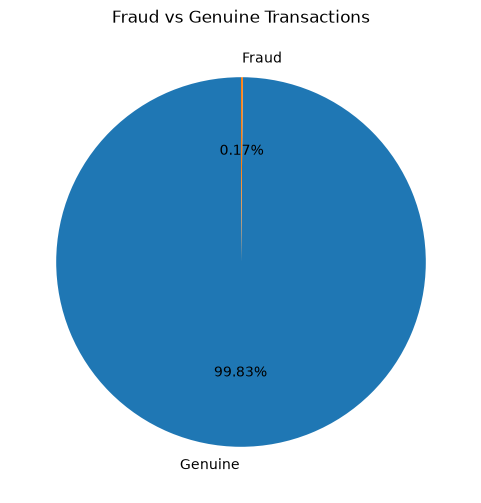

In [80]:
fraud = df['Class'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(fraud,
        labels=['Genuine','Fraud'],
        autopct='%1.2f%%',
        startangle=90)

plt.title("Fraud vs Genuine Transactions")

plt.show()

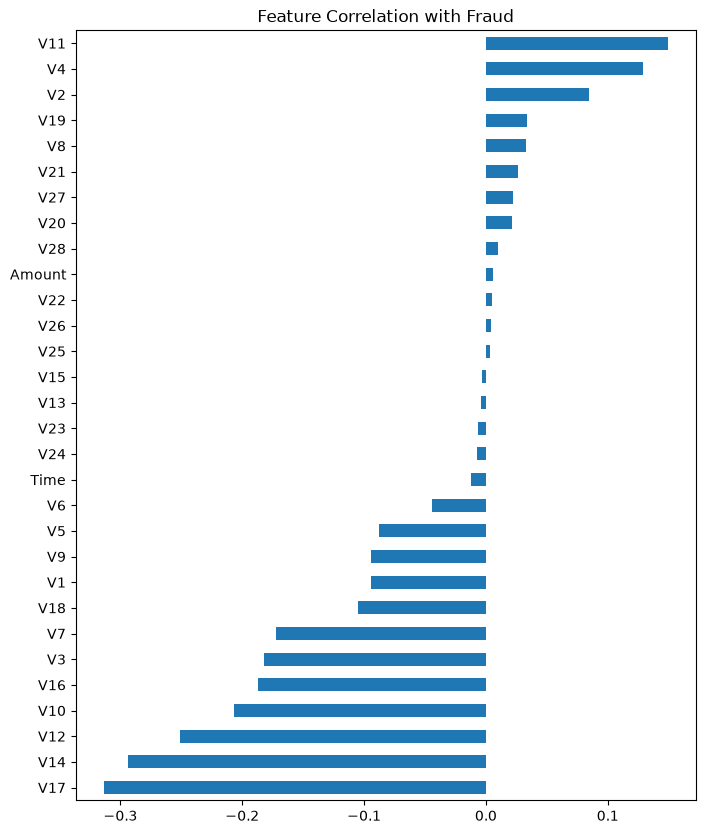

In [81]:
corr = df.corr()['Class'].sort_values()

plt.figure(figsize=(8,10))

corr.drop('Class').plot(kind='barh')

plt.title("Feature Correlation with Fraud")
plt.show()

In [82]:
df.shape

(283726, 31)

In [83]:
df['Class'].value_counts

<bound method IndexOpsMixin.value_counts of 0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 283726, dtype: int64>

In [84]:
x = df.drop('Class', axis=1)
y = df['Class']

In [85]:
df.head(5) 
# (All columns are numerical so no need to use simple imputer or ohe or columnsTransformer)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [86]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 42, stratify = y)  
# (Stratify will make sure the fraud and non fraud ration distribution is equal in train and test data)

In [87]:
print("Training Features:", x_train.shape)
print("Testing Features :", x_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (226980, 30)
Testing Features : (56746, 30)
Training Labels  : (226980,)
Testing Labels   : (56746,)


In [88]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [89]:
y_pred = gb.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(56746,))

In [90]:
y_prob = gb.predict_proba(x_test)[:,1]
y_prob
# Predict probability of fraud

array([0.00021563, 0.00021563, 0.00052836, ..., 0.00021563, 0.00021563,
       0.00021563], shape=(56746,))

In [91]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [93]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9992422373383146


In [94]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.8611111111111112


In [95]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6526315789473685


In [96]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7425149700598802


In [97]:
roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8539261164154672


In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.65      0.74        95

    accuracy                           1.00     56746
   macro avg       0.93      0.83      0.87     56746
weighted avg       1.00      1.00      1.00     56746



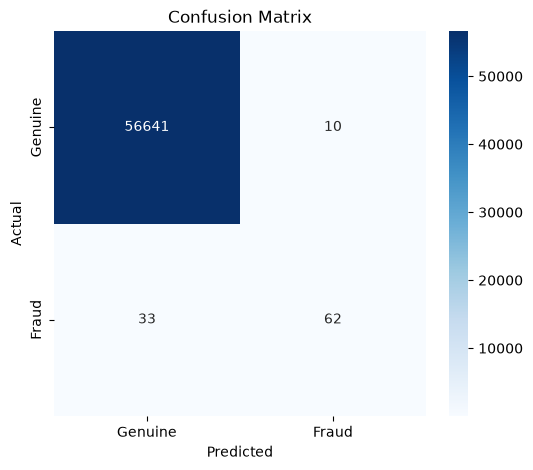

In [99]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [100]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': gb.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
17,V17,0.509890
4,V4,0.137990
8,V8,0.095564
14,V14,0.049228
18,V18,0.040036
10,V10,0.030866
26,V26,0.030820
27,V27,0.021569
6,V6,0.012428
15,V15,0.010787


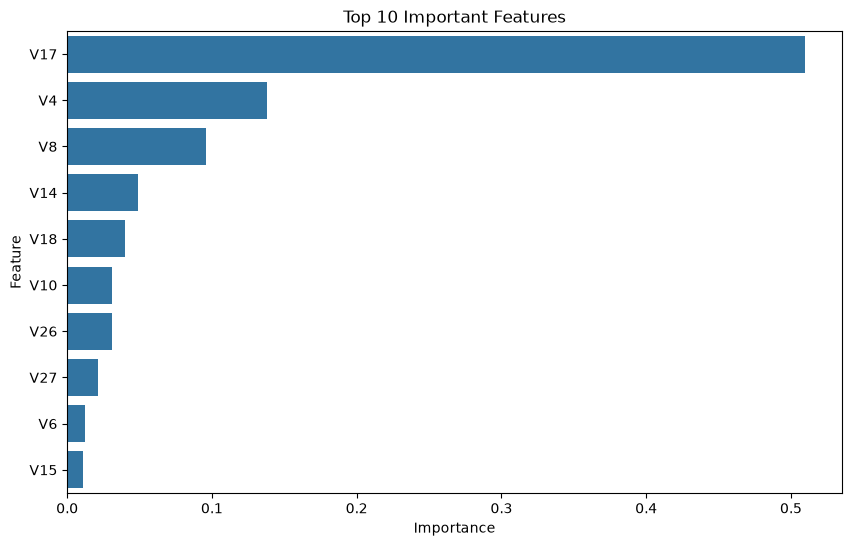

In [101]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10), x='Importance', y='Feature')

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [102]:
import pickle

with open("gradient_boosting_model.pkl", "wb") as file:
    pickle.dump(gb, file)

print("Model saved successfully!")

Model saved successfully!


In [103]:
with open("gradient_boosting_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [104]:
sample = x_test.iloc[[0]]

prediction = loaded_model.predict(sample)

if prediction[0] == 0:
    print("Prediction: Genuine Transaction")
else:
    print("Prediction: Fraudulent Transaction")

Prediction: Genuine Transaction


In [105]:
# The model Predicted that it was a genuine transaction and not a fraud one!

In [106]:
sample2 = x_test.iloc[[50]]

prediction = loaded_model.predict(sample)

if prediction[0] == 0:
    print("Prediction: Genuine Transaction")
else:
    print("Prediction: Fraudulent Transaction")

Prediction: Genuine Transaction


In [107]:
# Multiple transactions prediction

samples = x_test.iloc[:5]

predictions = loaded_model.predict(samples)
print("Predictions:")
print(predictions)

Predictions:
[0 0 0 0 0]


In [108]:
#All are genuine transactions (Non-fraud) - 
# The model predicted all selected transactions as Genuine (Class 0), which is consistent with its strong overall performance
# on the test data.

In [109]:
# This project developed a Credit Card Fraud Detection System using the Gradient Boosting Classifier. 
# The model was trained on a dataset containing both legitimate (Genuine) and fraudulent transactions and evaluated using multiple performance metrics.
# Since the dataset is highly imbalanced, evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC were considered along with Accuracy.
# These metrics provide a better understanding of the model's ability to correctly identify fraudulent transactions while minimizing false alarms.
# The trained model demonstrated good performance in distinguishing fraudulent transactions from legitimate ones, 
# making Gradient Boosting an effective choice for this classification task.

In [110]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [ accuracy, precision, recall, f1, roc ]
})

results

,Metric,Score
0,Accuracy,0.999242
1,Precision,0.861111
2,Recall,0.652632
3,F1 Score,0.742515
4,ROC-AUC,0.853926


In [111]:
# The model demonstrates strong performance by achieving high accuracy (99.92%) while also maintaining 
# good Precision, Recall, F1-Score, and ROC-AUC, indicating effective fraud detection.

In [112]:
# 1. The Gradient Boosting Classifier achieved an overall Accuracy of 99.92%, indicating excellent classification performance.
# 2. The model achieved 86.11% Precision, meaning most transactions predicted as fraudulent were correctly identified.
# 3. An ROC-AUC score of 85.39% demonstrates the model's strong ability to distinguish between genuine and fraudulent transactions.
# 4. Since the dataset is highly imbalanced, Precision, Recall, F1-Score, and ROC-AUC provide a more meaningful evaluation than Accuracy alone.
# 5. This model can be used as an effective decision-support tool to help financial institutions detect fraudulent transactions and reduce financial losses.

In [113]:
# 1. Apply SMOTE or other resampling techniques to handle class imbalance and improve fraud detection performance.
# 2. Optimize the model using hyperparameter tuning (GridSearchCV or RandomizedSearchCV) to enhance Precision, Recall, and F1-Score.
# 3. Deploy the model as a real-time web application using Streamlit, Flask, or FastAPI for live credit card fraud detection.